# Prepare

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from enum import Enum


class Library(str, Enum):
    DEEPEVAL = 'deepeval'
    RAGAS = 'ragas'
    TRULENS = 'trulens'
    PHOENIX = 'phoenix'
    MLFLOW = 'mlflow'
    RAGCHECKER = 'ragchecker'
    LLAMA_INDEX = 'llama_index'
    TONIC_VALIDATE = 'tonic_validate'

In [3]:
from eval_fusion_core.base import EvalFusionBaseMetric
from eval_fusion_deepeval.metrics import DeepEvalMetric
from eval_fusion_llama_index.metrics import LlamaIndexMetric
from eval_fusion_mlflow.metrics import MlFlowMetric
from eval_fusion_phoenix.metrics import PhoenixMetric
from eval_fusion_ragas.metrics import RagasMetric
from eval_fusion_ragchecker.metrics import RagCheckerMetric
from eval_fusion_tonic_validate.metrics import TonicValidateMetric
from eval_fusion_trulens.metrics import TruLensMetric

/Users/lukapanic/Documents/Projects/eval-fusion/libs/test/.venv/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
INFO:phoenix.config:📋 Ensuring phoenix working directory: /Users/lukapanic/.phoenix
INFO:phoenix.inferences.inferences:Dataset: phoenix_inferences_49078f55-ff43-4d7f-b39e-3cd7cf187af6 initialized
W0730 01:32:55.110000 11234 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
INFO:httpx:HTTP Request: GET https://raw.githubusercontent.com/BerriAI/litellm/main/model_prices_and_context_window.json "HTTP/1.1 200 OK"
/Users/lukapanic/Documents/Projects/eval-fusion/libs/test/.venv/lib/python3.12/site-packages/munch/__init__.py:24: 

In [4]:
from eval_fusion_core.models import EvaluationOutput, TokenUsage
from pydantic import BaseModel


class EvaluationResult(BaseModel):
    outputs: list[EvaluationOutput]
    token_usage: TokenUsage | tuple[TokenUsage, TokenUsage] | None

In [5]:
def load_evaluation_result(
    llm_name: str,
    metric: EvalFusionBaseMetric,
    library: Library,
) -> EvaluationResult:
    file_path = f'outputs/{llm_name}/{library.value}/{metric.value}.json'

    with open(file_path, 'r') as file:
        data = file.read()

        return EvaluationResult.model_validate_json(data)

In [6]:
def get_data_frame(
    llm_name: str, library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]]
) -> pd.DataFrame:
    library_name_to_result = {
        library.value: load_evaluation_result(
            llm_name=llm_name,
            metric=metric,
            library=library,
        )
        for library, metric in library_metric_tuples
    }
    data = {
        library_name: [output.output_entries[0].score for output in result.outputs]
        for library_name, result in library_name_to_result.items()
    }
    num_samples = len(next(iter(library_name_to_result.values())).outputs)

    df = pd.DataFrame(data)
    df.index = [i for i in range(num_samples)]

    return df

In [7]:
def plot_heatmap(df: pd.DataFrame):
    plt.figure(figsize=(8, 8))
    sns.heatmap(df, annot=df, fmt='.2f', cmap='coolwarm', cbar=True)
    plt.xlabel('Framework')
    plt.ylabel('Sample')
    plt.tight_layout()
    plt.show()

In [8]:
def plot_line(df: pd.DataFrame, frameworks: list[str]):
    plt.figure(figsize=(10, 5))

    for framework in frameworks:
        plt.plot(
            df.index,
            df[framework],
            marker='s',
            linestyle='--',
            label=framework,
            linewidth=2,
            alpha=0.9,
        )

    plt.xlabel('Sample')
    plt.ylabel('Score')
    plt.legend(title='Framework', loc='upper right')
    plt.grid(True, zorder=0)

    x_min, x_max = plt.xlim()
    plt.xticks(np.arange(int(x_min), int(x_max) + 1, 1))

    plt.tight_layout()
    plt.show()

In [9]:
def get_spearman_rank(df: pd.DataFrame) -> pd.DataFrame:
    corr = df.corr(method='spearman').fillna(0)  # avoid None for the constant columns
    styled_corr = corr.style.background_gradient(cmap='coolwarm').format('{:.2f}')

    return styled_corr

In [10]:
def plot_spearman_rank_heatmap(df: pd.DataFrame):
    corr = df.corr(method='spearman').fillna(0)

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar=True
    )
    plt.tight_layout()
    plt.show()

# Plot

## gpt-4o-mini

In [11]:
llm_name = 'gpt-4o-mini'
em_name = 'text-embedding-3-large'

### faithfulness

In [16]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.DEEPEVAL, DeepEvalMetric.FAITHFULNESS),
    (Library.RAGAS, RagasMetric.FAITHFULNESS),
    (Library.MLFLOW, MlFlowMetric.FAITHFULNESS),
    (Library.RAGCHECKER, RagCheckerMetric.FAITHFULNESS),
    (Library.LLAMA_INDEX, LlamaIndexMetric.FAITHFULNESS),
]

In [17]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,deepeval,ragas,mlflow,ragchecker,llama_index
deepeval,1.00,0.34,0.71,0.29,0.61
ragas,0.34,1.00,0.49,0.83,0.32
mlflow,0.71,0.49,1.00,0.48,0.68
ragchecker,0.29,0.83,0.48,1.00,0.38
llama_index,0.61,0.32,0.68,0.38,1.00


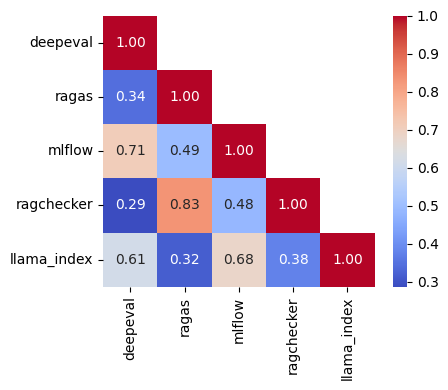

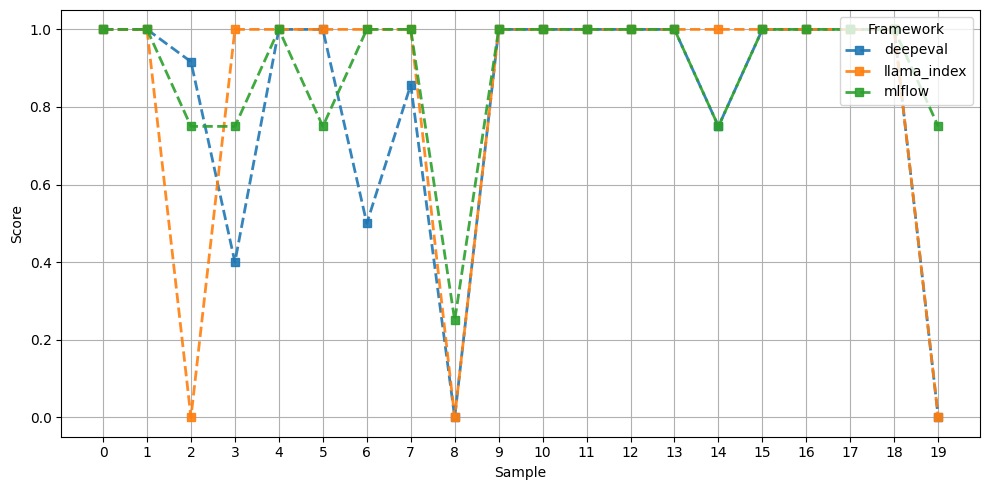

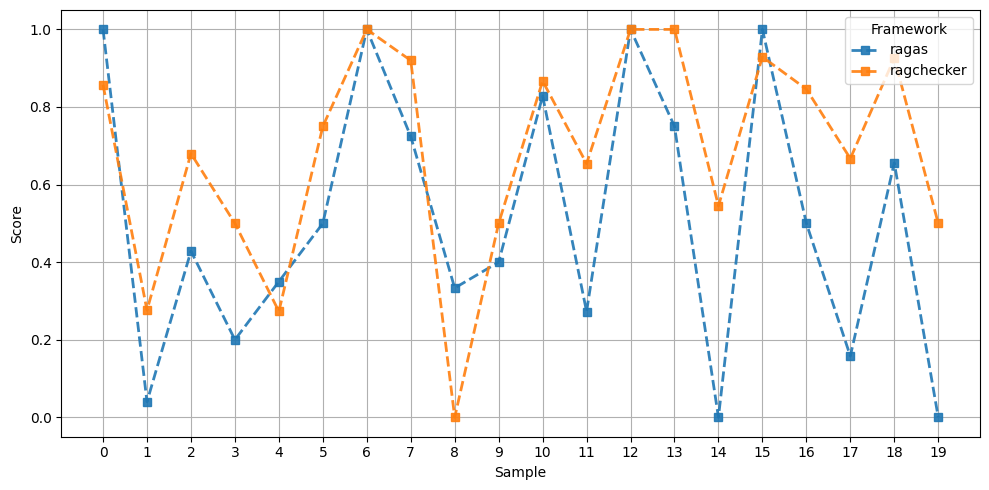

In [18]:
plot_spearman_rank_heatmap(df)
plot_line(df, ['deepeval', 'llama_index', 'mlflow'])
plot_line(df, ['ragas', 'ragchecker'])

### context_precision/contextual_precision

In [19]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.RAGAS, RagasMetric.CONTEXT_PRECISION),
    (Library.RAGCHECKER, RagCheckerMetric.CONTEXT_PRECISION),
    (Library.DEEPEVAL, DeepEvalMetric.CONTEXTUAL_PRECISION),
]

In [20]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,ragas,ragchecker,deepeval
ragas,1.00,0.08,0.47
ragchecker,0.08,1.00,0.04
deepeval,0.47,0.04,1.00


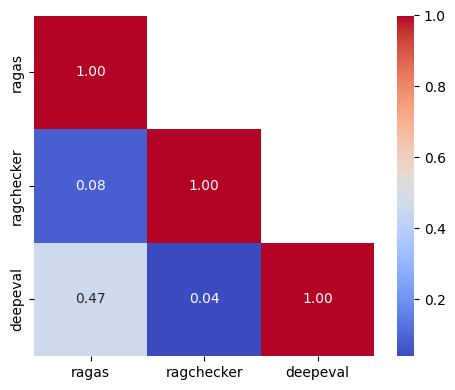

In [22]:
plot_spearman_rank_heatmap(df)

### context_recall/contextual_recall

In [24]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.RAGAS, RagasMetric.CONTEXT_RECALL),
    (Library.DEEPEVAL, DeepEvalMetric.CONTEXTUAL_RECALL),
]

In [25]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,ragas,deepeval
ragas,1.00,-0.14
deepeval,-0.14,1.00


### answer_relevance/answer_relevancy/response_relevancy

In [26]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.ANSWER_RELEVANCE),
    (Library.DEEPEVAL, DeepEvalMetric.ANSWER_RELEVANCY),
    (Library.LLAMA_INDEX, LlamaIndexMetric.ANSWER_RELEVANCY),
    (Library.RAGAS, RagasMetric.RESPONSE_RELEVANCY),
]

In [27]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,mlflow,deepeval,llama_index,ragas
mlflow,1.00,0.54,0.46,0.36
deepeval,0.54,1.00,0.40,0.36
llama_index,0.46,0.40,1.00,0.69
ragas,0.36,0.36,0.69,1.00


### answer_correctness/correctness

In [28]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.ANSWER_CORRECTNESS),
    (Library.LLAMA_INDEX, LlamaIndexMetric.CORRECTNESS),
]

In [29]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,mlflow,llama_index
mlflow,1.00,0.31
llama_index,0.31,1.00


### relevance/relevancy

In [30]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.RELEVANCE),
    (Library.PHOENIX, PhoenixMetric.RELEVANCE),
    (Library.LLAMA_INDEX, LlamaIndexMetric.RELEVANCY),
]

In [33]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,mlflow,phoenix,llama_index
mlflow,1.00,0.00,0.84
phoenix,0.00,0.00,0.00
llama_index,0.84,0.00,1.00


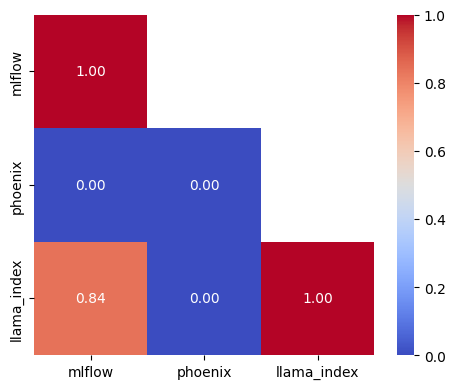

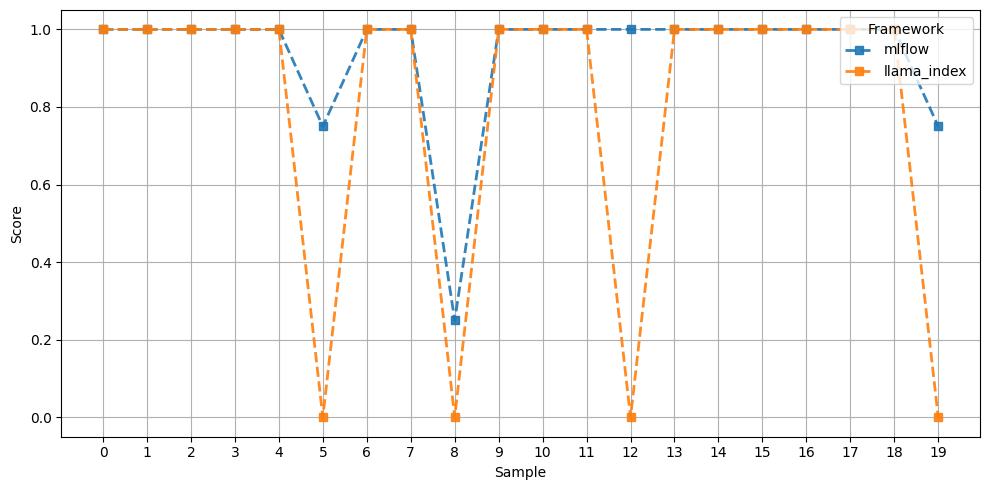

In [36]:
plot_spearman_rank_heatmap(df)
plot_line(df, ['mlflow', 'llama_index'])

### answer_similarity/semantic_similarity

In [42]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.ANSWER_SIMILARITY),
    (Library.TONIC_VALIDATE, TonicValidateMetric.ANSWER_SIMILARITY),
    (Library.LLAMA_INDEX, LlamaIndexMetric.SEMANTIC_SIMILARITY),
]

In [43]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,mlflow,tonic_validate,llama_index
mlflow,1.00,0.64,0.39
tonic_validate,0.64,1.00,0.54
llama_index,0.39,0.54,1.00


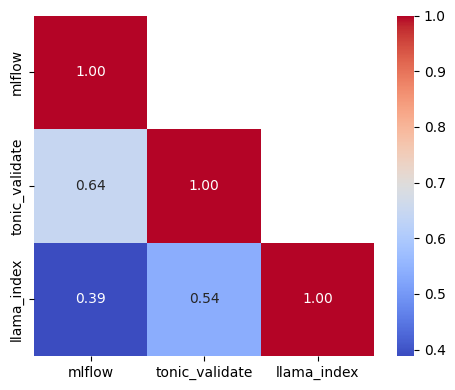

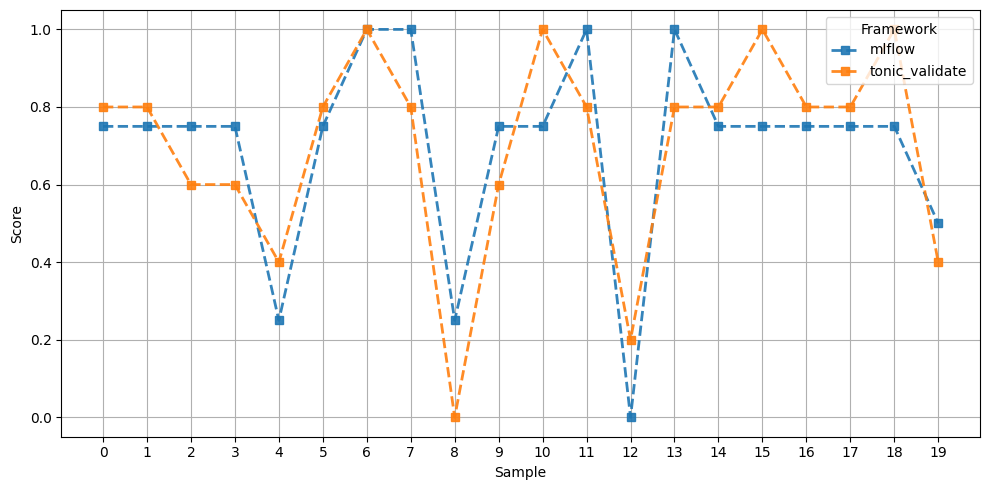

In [44]:
plot_spearman_rank_heatmap(df)
plot_line(df, ['mlflow', 'tonic_validate'])

### context_relevance/context_relevancy/contextual_relevancy

In [46]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.TRULENS, TruLensMetric.CONTEXT_RELEVANCE),
    (Library.LLAMA_INDEX, LlamaIndexMetric.CONTEXT_RELEVANCY),
    (Library.DEEPEVAL, DeepEvalMetric.CONTEXTUAL_RELEVANCY),
]

In [47]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,trulens,llama_index,deepeval
trulens,1.00,0.35,0.22
llama_index,0.35,1.00,0.07
deepeval,0.22,0.07,1.00


## gpt-4o

In [58]:
llm_name = 'gpt-4o'
em_name = 'text-embedding-3-large'

### faithfulness

In [59]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.DEEPEVAL, DeepEvalMetric.FAITHFULNESS),
    (Library.RAGAS, RagasMetric.FAITHFULNESS),
    (Library.MLFLOW, MlFlowMetric.FAITHFULNESS),
    (Library.RAGCHECKER, RagCheckerMetric.FAITHFULNESS),
    (Library.LLAMA_INDEX, LlamaIndexMetric.FAITHFULNESS),
]

In [ ]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,deepeval,ragas,mlflow,ragchecker,llama_index
deepeval,1.00,0.32,0.09,-0.05,0.33
ragas,0.32,1.00,0.78,0.77,0.45
mlflow,0.09,0.78,1.00,0.89,0.57
ragchecker,-0.05,0.77,0.89,1.00,0.40
llama_index,0.33,0.45,0.57,0.40,1.00


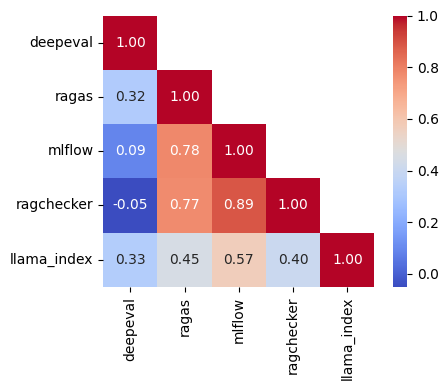

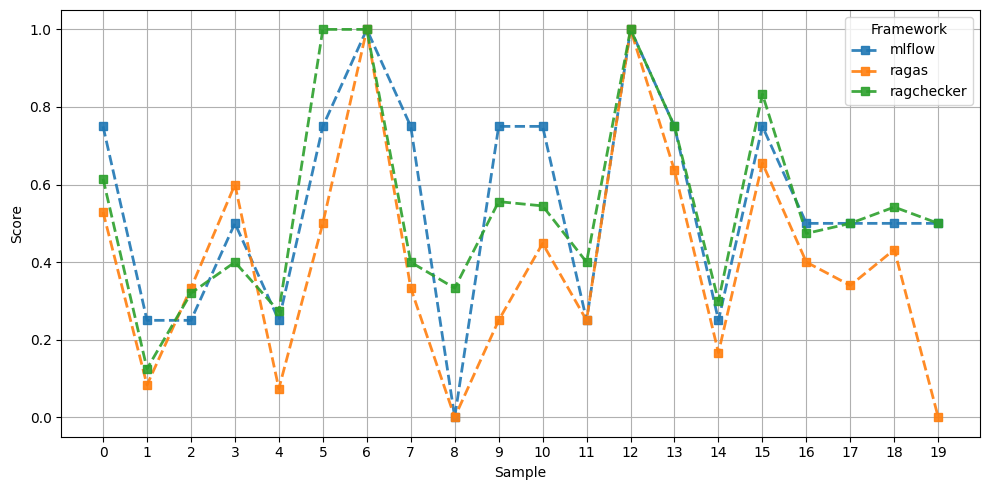

In [63]:
plot_spearman_rank_heatmap(df)
plot_line(df, ['mlflow', 'ragas', 'ragchecker'])

### context_precision/contextual_precision

In [64]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.RAGAS, RagasMetric.CONTEXT_PRECISION),
    (Library.RAGCHECKER, RagCheckerMetric.CONTEXT_PRECISION),
    (Library.DEEPEVAL, DeepEvalMetric.CONTEXTUAL_PRECISION),
]

In [65]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,ragas,ragchecker,deepeval
ragas,1.00,0.39,0.46
ragchecker,0.39,1.00,0.22
deepeval,0.46,0.22,1.00


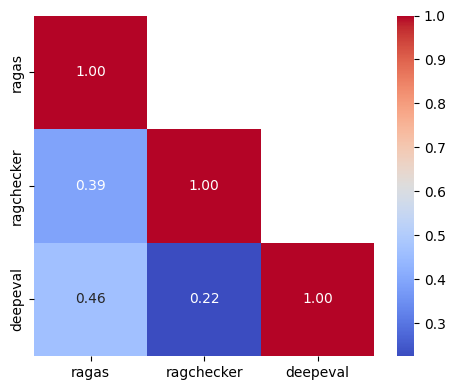

In [66]:
plot_spearman_rank_heatmap(df)

### context_recall/contextual_recall

In [67]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.RAGAS, RagasMetric.CONTEXT_RECALL),
    (Library.DEEPEVAL, DeepEvalMetric.CONTEXTUAL_RECALL),
]

In [68]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,ragas,deepeval
ragas,0.00,0.00
deepeval,0.00,1.00


### answer_relevance/answer_relevancy/response_relevancy

In [69]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.ANSWER_RELEVANCE),
    (Library.DEEPEVAL, DeepEvalMetric.ANSWER_RELEVANCY),
    (Library.LLAMA_INDEX, LlamaIndexMetric.ANSWER_RELEVANCY),
    (Library.RAGAS, RagasMetric.RESPONSE_RELEVANCY),
]

In [70]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,mlflow,deepeval,llama_index,ragas
mlflow,1.00,0.59,0.51,0.03
deepeval,0.59,1.00,0.58,0.32
llama_index,0.51,0.58,1.00,0.26
ragas,0.03,0.32,0.26,1.00


### answer_correctness/correctness

In [71]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.ANSWER_CORRECTNESS),
    (Library.LLAMA_INDEX, LlamaIndexMetric.CORRECTNESS),
]

In [72]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,mlflow,llama_index
mlflow,1.00,0.74
llama_index,0.74,1.00


### relevance/relevancy

In [73]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.RELEVANCE),
    (Library.PHOENIX, PhoenixMetric.RELEVANCE),
    (Library.LLAMA_INDEX, LlamaIndexMetric.RELEVANCY),
]

In [74]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,mlflow,phoenix,llama_index
mlflow,1.00,0.00,0.78
phoenix,0.00,0.00,0.00
llama_index,0.78,0.00,1.00


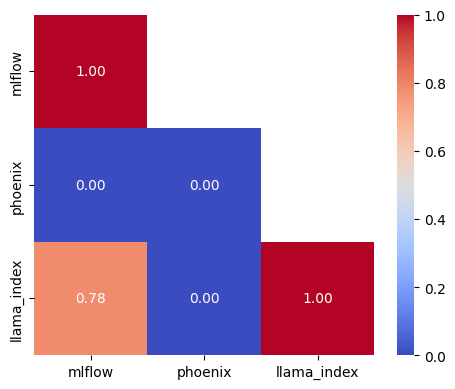

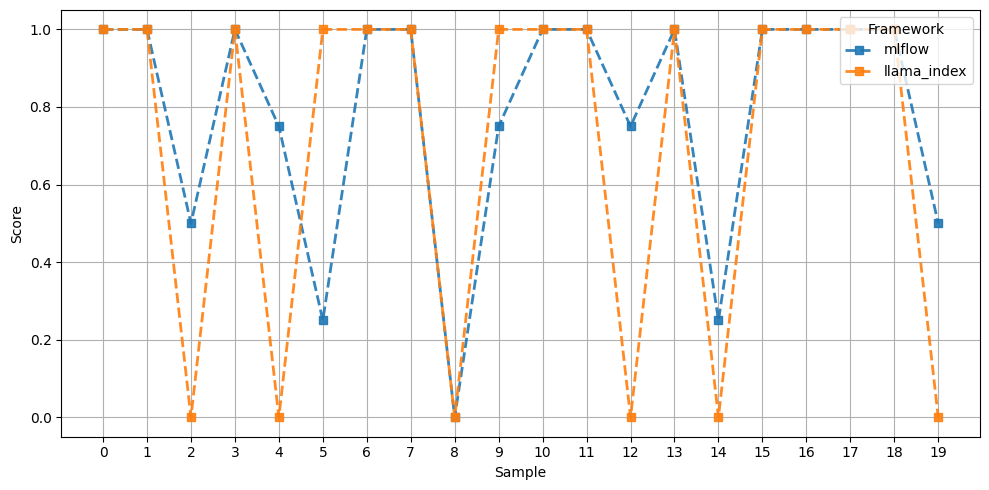

In [75]:
plot_spearman_rank_heatmap(df)
plot_line(df, ['mlflow', 'llama_index'])

### answer_similarity/semantic_similarity

In [76]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.ANSWER_SIMILARITY),
    (Library.TONIC_VALIDATE, TonicValidateMetric.ANSWER_SIMILARITY),
    (Library.LLAMA_INDEX, LlamaIndexMetric.SEMANTIC_SIMILARITY),
]

In [77]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,mlflow,tonic_validate,llama_index
mlflow,1.00,0.86,0.62
tonic_validate,0.86,1.00,0.80
llama_index,0.62,0.80,1.00


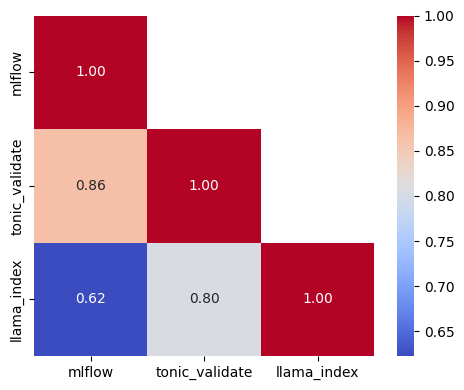

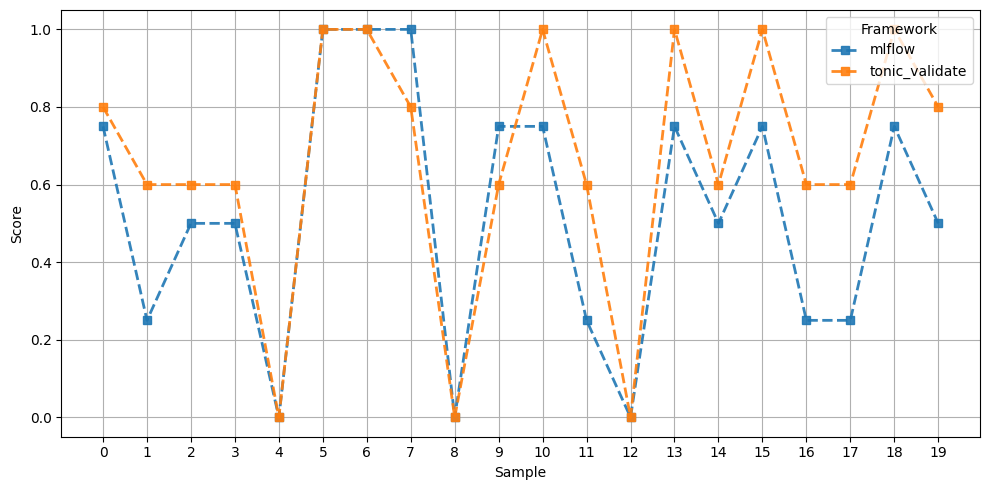

In [78]:
plot_spearman_rank_heatmap(df)
plot_line(df, ['mlflow', 'tonic_validate'])

### context_relevance/context_relevancy/contextual_relevancy

In [79]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.TRULENS, TruLensMetric.CONTEXT_RELEVANCE),
    (Library.LLAMA_INDEX, LlamaIndexMetric.CONTEXT_RELEVANCY),
    (Library.DEEPEVAL, DeepEvalMetric.CONTEXTUAL_RELEVANCY),
]

In [80]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,trulens,llama_index,deepeval
trulens,1.00,0.39,0.38
llama_index,0.39,1.00,0.27
deepeval,0.38,0.27,1.00


## llama3.1-405b-instruct-fp8

In [13]:
llm_name = 'llama3.1-405b-instruct-fp8'
em_name = 'text-embedding-3-large'

### faithfulness

In [17]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    # (Library.DEEPEVAL, DeepEvalMetric.FAITHFULNESS),  # NOTE: deepeval failed with this LLM
    (Library.RAGAS, RagasMetric.FAITHFULNESS),
    (Library.MLFLOW, MlFlowMetric.FAITHFULNESS),
    (Library.RAGCHECKER, RagCheckerMetric.FAITHFULNESS),
    (Library.LLAMA_INDEX, LlamaIndexMetric.FAITHFULNESS),
]

In [18]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,ragas,mlflow,ragchecker,llama_index
ragas,1.00,0.47,0.75,0.52
mlflow,0.47,1.00,0.63,0.03
ragchecker,0.75,0.63,1.00,0.25
llama_index,0.52,0.03,0.25,1.00


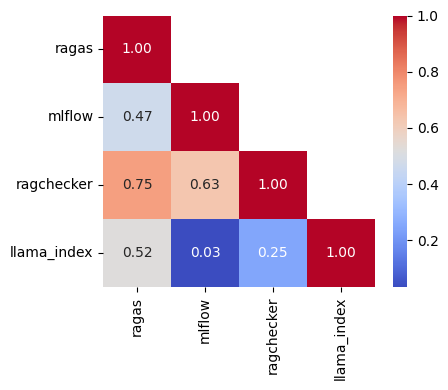

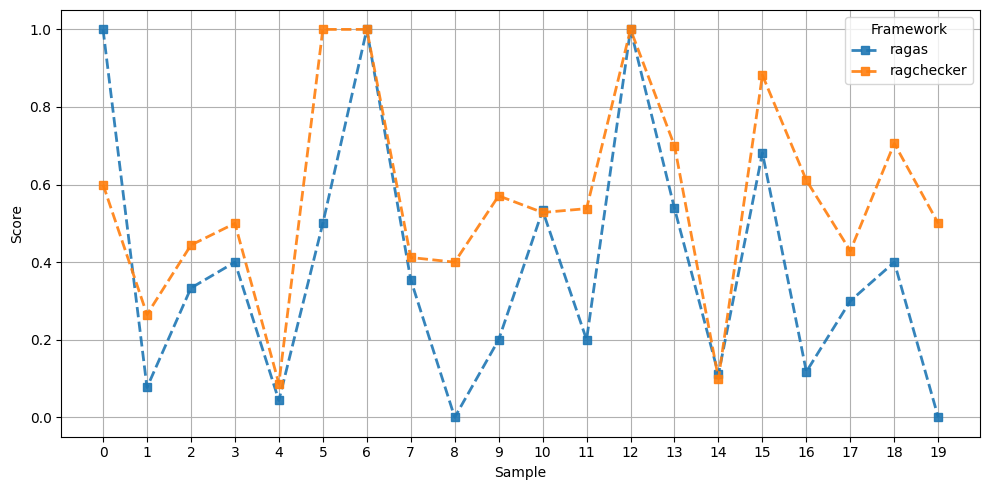

In [19]:
plot_spearman_rank_heatmap(df)
plot_line(df, ['ragas', 'ragchecker'])

### context_precision/contextual_precision

In [20]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.RAGAS, RagasMetric.CONTEXT_PRECISION),
    (Library.RAGCHECKER, RagCheckerMetric.CONTEXT_PRECISION),
    (Library.DEEPEVAL, DeepEvalMetric.CONTEXTUAL_PRECISION),
]

In [21]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,ragas,ragchecker,deepeval
ragas,1.00,0.66,0.72
ragchecker,0.66,1.00,0.48
deepeval,0.72,0.48,1.00


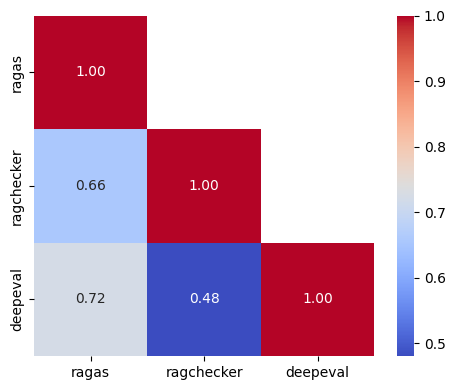

In [22]:
plot_spearman_rank_heatmap(df)

### context_recall/contextual_recall

In [23]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.RAGAS, RagasMetric.CONTEXT_RECALL),
    (Library.DEEPEVAL, DeepEvalMetric.CONTEXTUAL_RECALL),
]

In [24]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,ragas,deepeval
ragas,0.00,0.00
deepeval,0.00,1.00


### answer_relevance/answer_relevancy/response_relevancy

In [ ]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.ANSWER_RELEVANCE),
    (Library.DEEPEVAL, DeepEvalMetric.ANSWER_RELEVANCY),
    (Library.LLAMA_INDEX, LlamaIndexMetric.ANSWER_RELEVANCY),
    (Library.RAGAS, RagasMetric.RESPONSE_RELEVANCY),
]

In [26]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,mlflow,deepeval,llama_index,ragas
mlflow,0.00,0.00,0.00,0.00
deepeval,0.00,1.00,-0.10,0.21
llama_index,0.00,-0.10,1.00,-0.37
ragas,0.00,0.21,-0.37,1.00


### answer_correctness/correctness

In [27]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.ANSWER_CORRECTNESS),
    (Library.LLAMA_INDEX, LlamaIndexMetric.CORRECTNESS),
]

In [28]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,mlflow,llama_index
mlflow,1.00,0.58
llama_index,0.58,1.00


### relevance/relevancy

In [29]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.RELEVANCE),
    (Library.PHOENIX, PhoenixMetric.RELEVANCE),
    (Library.LLAMA_INDEX, LlamaIndexMetric.RELEVANCY),
]

In [30]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,mlflow,phoenix,llama_index
mlflow,1.00,0.00,0.70
phoenix,0.00,0.00,0.00
llama_index,0.70,0.00,1.00


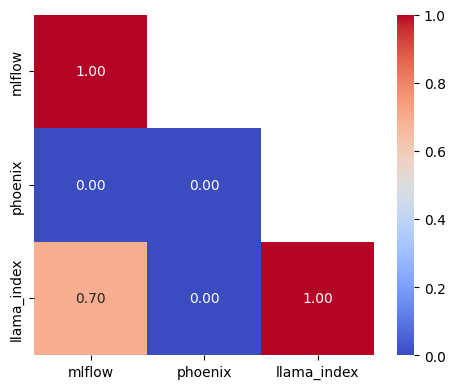

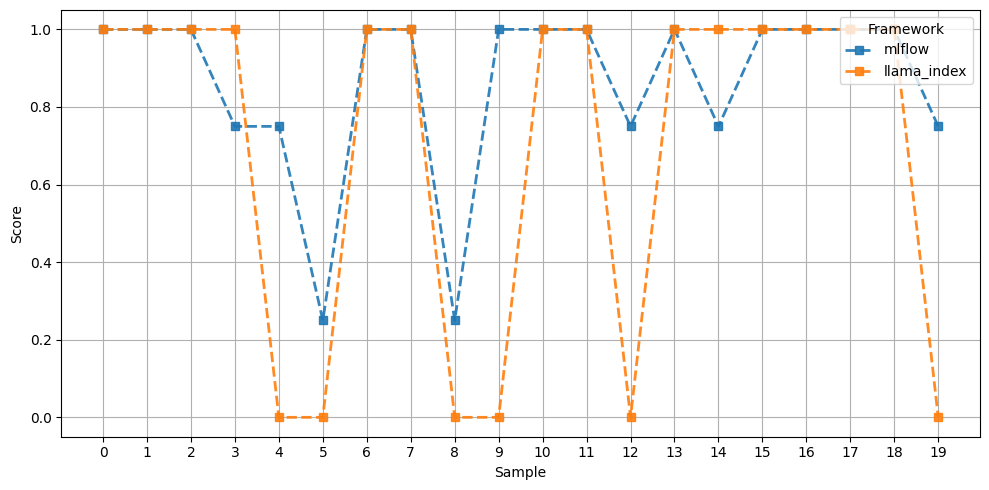

In [31]:
plot_spearman_rank_heatmap(df)
plot_line(df, ['mlflow', 'llama_index'])

### answer_similarity/semantic_similarity

In [34]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.ANSWER_SIMILARITY),
    # (Library.TONIC_VALIDATE, TonicValidateMetric.ANSWER_SIMILARITY),
    (Library.LLAMA_INDEX, LlamaIndexMetric.SEMANTIC_SIMILARITY),
]

In [35]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,mlflow,llama_index
mlflow,1.00,0.69
llama_index,0.69,1.00


### context_relevance/context_relevancy/contextual_relevancy

In [36]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.TRULENS, TruLensMetric.CONTEXT_RELEVANCE),
    (Library.LLAMA_INDEX, LlamaIndexMetric.CONTEXT_RELEVANCY),
    (Library.DEEPEVAL, DeepEvalMetric.CONTEXTUAL_RELEVANCY),
]

In [37]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,trulens,llama_index,deepeval
trulens,1.00,0.50,0.48
llama_index,0.50,1.00,0.58
deepeval,0.48,0.58,1.00


## llama3.1-70b-instruct-fp8

In [38]:
llm_name = 'llama3.1-70b-instruct-fp8'
em_name = 'text-embedding-3-large'

### faithfulness

In [ ]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.DEEPEVAL, DeepEvalMetric.FAITHFULNESS),
    (Library.RAGAS, RagasMetric.FAITHFULNESS),
    (Library.MLFLOW, MlFlowMetric.FAITHFULNESS),
    (Library.RAGCHECKER, RagCheckerMetric.FAITHFULNESS),
    (Library.LLAMA_INDEX, LlamaIndexMetric.FAITHFULNESS),
]

In [40]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

,deepeval,ragas,mlflow,ragchecker,llama_index
deepeval,1.00,0.15,0.08,-0.17,0.14
ragas,0.15,1.00,0.41,0.77,0.19
mlflow,0.08,0.41,1.00,0.53,0.54
ragchecker,-0.17,0.77,0.53,1.00,0.46
llama_index,0.14,0.19,0.54,0.46,1.00


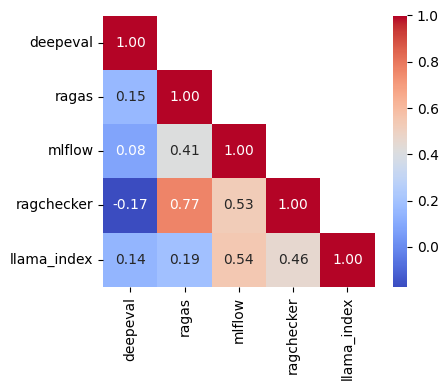

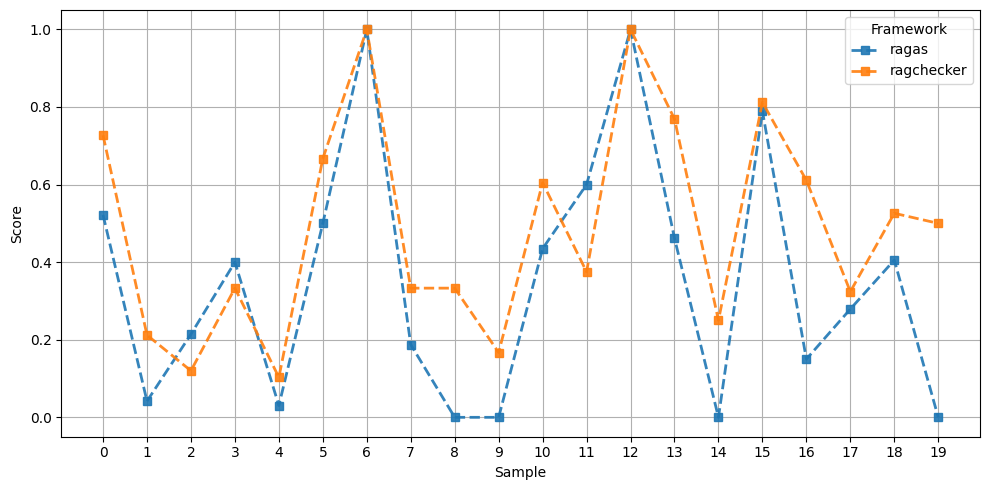

In [41]:
plot_spearman_rank_heatmap(df)
plot_line(df, ['ragas', 'ragchecker'])

### context_precision/contextual_precision

In [42]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.RAGAS, RagasMetric.CONTEXT_PRECISION),
    (Library.RAGCHECKER, RagCheckerMetric.CONTEXT_PRECISION),
    (Library.DEEPEVAL, DeepEvalMetric.CONTEXTUAL_PRECISION),
]

In [ ]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

In [ ]:
plot_spearman_rank_heatmap(df)

### context_recall/contextual_recall

In [44]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.RAGAS, RagasMetric.CONTEXT_RECALL),
    (Library.DEEPEVAL, DeepEvalMetric.CONTEXTUAL_RECALL),
]

In [ ]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

### answer_relevance/answer_relevancy/response_relevancy

In [46]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.ANSWER_RELEVANCE),
    (Library.DEEPEVAL, DeepEvalMetric.ANSWER_RELEVANCY),
    (Library.LLAMA_INDEX, LlamaIndexMetric.ANSWER_RELEVANCY),
    (Library.RAGAS, RagasMetric.RESPONSE_RELEVANCY),
]

In [ ]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

### answer_correctness/correctness

In [ ]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.ANSWER_CORRECTNESS),
    (Library.LLAMA_INDEX, LlamaIndexMetric.CORRECTNESS),
]

In [ ]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

### relevance/relevancy

In [ ]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.RELEVANCE),
    (Library.PHOENIX, PhoenixMetric.RELEVANCE),
    (Library.LLAMA_INDEX, LlamaIndexMetric.RELEVANCY),
]

In [ ]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

In [ ]:
plot_spearman_rank_heatmap(df)
plot_line(df, ['mlflow', 'llama_index'])

### answer_similarity/semantic_similarity

In [ ]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.MLFLOW, MlFlowMetric.ANSWER_SIMILARITY),
    # (Library.TONIC_VALIDATE, TonicValidateMetric.ANSWER_SIMILARITY),
    (Library.LLAMA_INDEX, LlamaIndexMetric.SEMANTIC_SIMILARITY),
]

In [ ]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)

### context_relevance/context_relevancy/contextual_relevancy

In [ ]:
library_metric_tuples: list[tuple[Library, EvalFusionBaseMetric]] = [
    (Library.TRULENS, TruLensMetric.CONTEXT_RELEVANCE),
    (Library.LLAMA_INDEX, LlamaIndexMetric.CONTEXT_RELEVANCY),
    (Library.DEEPEVAL, DeepEvalMetric.CONTEXTUAL_RELEVANCY),
]

In [ ]:
df = get_data_frame(llm_name, library_metric_tuples)
get_spearman_rank(df)